In [0]:
import pandas as pd
import numpy as np

# Load your cleaned data
df = pd.read_csv("/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv")

In [0]:
# Group by airline to find avg delays

carrier_stats = df.groupby("UniqueCarrier").agg({
    "ArrDelay": ["mean", "median", "std", "max", "min", "count"],
    "DepDelay": ["mean", "median", "std", "max", "min"]
}).round(2)
display(carrier_stats)

"('ArrDelay', 'mean')","('ArrDelay', 'median')","('ArrDelay', 'std')","('ArrDelay', 'max')","('ArrDelay', 'min')","('ArrDelay', 'count')","('DepDelay', 'mean')","('DepDelay', 'median')","('DepDelay', 'std')","('DepDelay', 'max')","('DepDelay', 'min')"
65.73,47.0,62.78,1525,15,73053,60.31,43.0,61.48,1521,6
57.56,39.0,55.39,948,15,10000,55.16,38.0,56.34,947,6
72.87,52.0,62.49,834,15,15364,68.28,48.0,63.0,846,6
59.29,39.0,57.06,863,15,30220,52.86,34.0,56.29,901,6
63.21,43.0,61.93,940,15,28678,61.38,42.0,62.0,965,6
41.97,29.0,39.68,706,15,9015,36.5,25.0,39.35,703,6
55.66,30.0,81.77,864,15,1440,52.75,28.0,81.05,866,6
64.28,46.0,63.98,1707,15,58698,57.82,41.0,61.16,1710,6
65.19,45.0,56.99,990,15,50384,60.37,42.0,55.24,996,6
69.67,49.0,60.34,1267,15,56896,66.37,48.0,59.91,1268,6


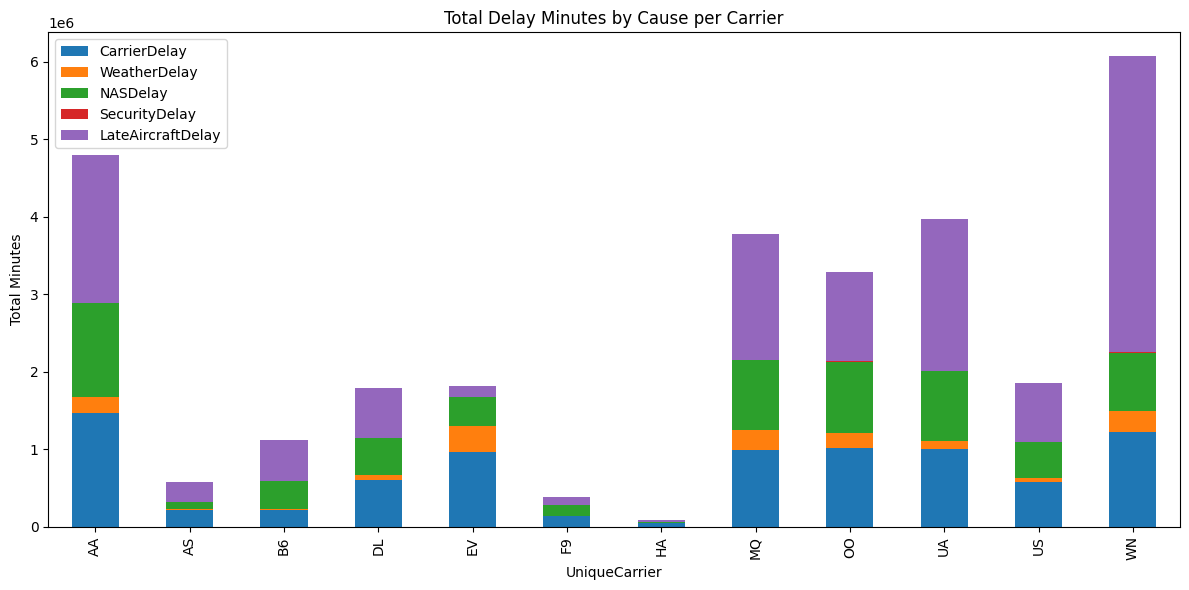

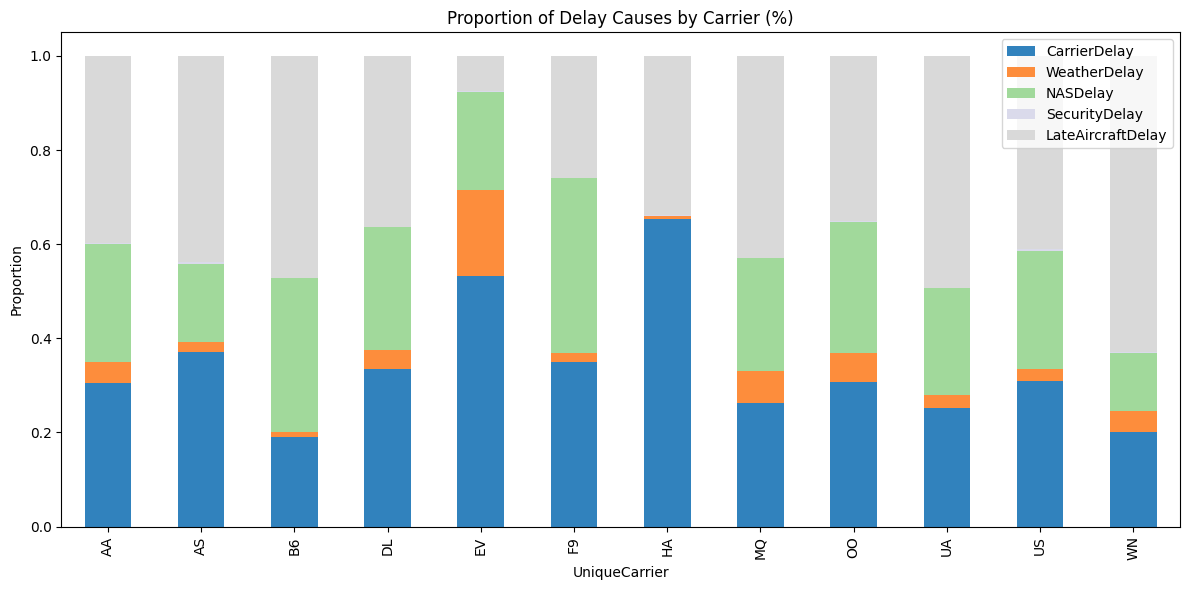

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Delay-Cause Composition (Carrier vs Weather vs NAS vs LateAircraft vs Security)

delay_causes = ["CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]
df[delay_causes] = df[delay_causes].fillna(0)

cause_by_carrier = df.groupby("UniqueCarrier")[delay_causes].sum()
cause_by_carrier_pct = cause_by_carrier.div(cause_by_carrier.sum(axis=1), axis=0)

# Stacked absolute
cause_by_carrier.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Total Delay Minutes by Cause per Carrier")
plt.ylabel("Total Minutes")
plt.tight_layout()
plt.show()

# Percent stacked
cause_by_carrier_pct.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20c")
plt.title("Proportion of Delay Causes by Carrier (%)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

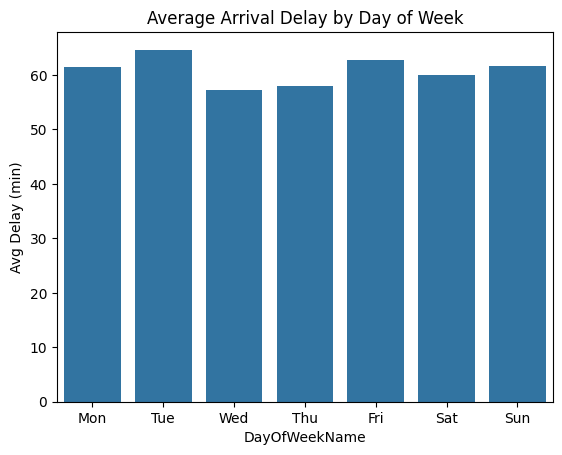

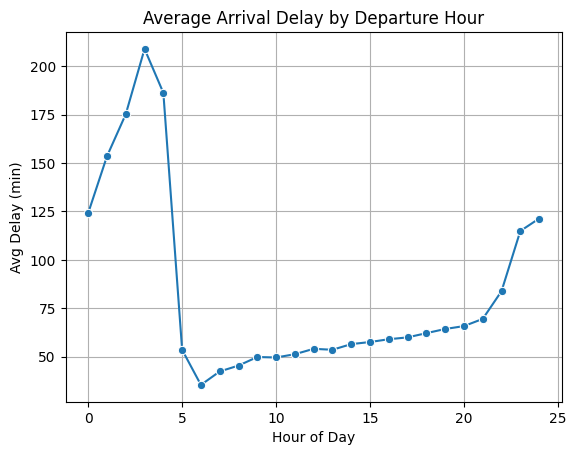

In [0]:
# Day-of-week mapping
dow_map = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
df["DayOfWeekName"] = df["DayOfWeek"].map(dow_map)

# Delays by day-of-week

dow_delay = df.groupby("DayOfWeekName")["ArrDelay"].mean().reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

sns.barplot(x=dow_delay.index, y=dow_delay.values)
plt.title("Average Arrival Delay by Day of Week")
plt.ylabel("Avg Delay (min)")
plt.show()

# Delay by hour of departure

def get_hour(x):
    try:
        return int(str(int(x)).zfill(4)[:2])
    except:
        return np.nan

df["DepHour"] = df["DepTime"].apply(get_hour)
hour_delay = df.groupby("DepHour")["ArrDelay"].mean().reset_index()

sns.lineplot(x="DepHour", y="ArrDelay", data=hour_delay, marker="o")
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Delay (min)")
plt.grid(True)
plt.show()

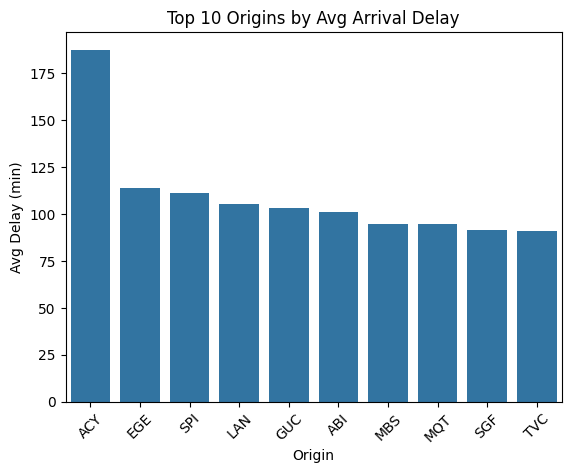

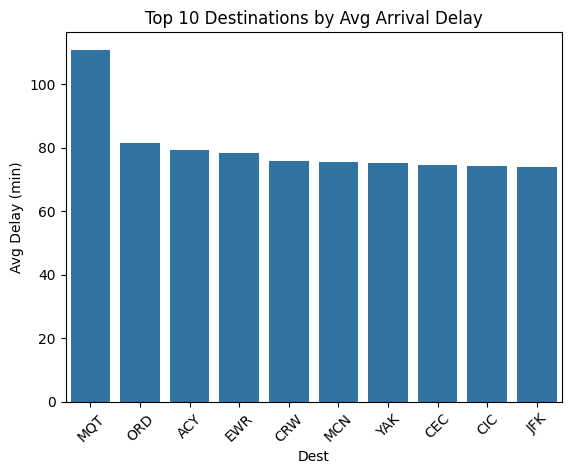

In [0]:
# Average delay by origin
origin_delay = df.groupby("Origin")["ArrDelay"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=origin_delay.index, y=origin_delay.values)
plt.title("Top 10 Origins by Avg Arrival Delay")
plt.ylabel("Avg Delay (min)")
plt.xticks(rotation=45)
plt.show()

# Destination
dest_delay = df.groupby("Dest")["ArrDelay"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=dest_delay.index, y=dest_delay.values)
plt.title("Top 10 Destinations by Avg Arrival Delay")
plt.ylabel("Avg Delay (min)")
plt.xticks(rotation=45)
plt.show()

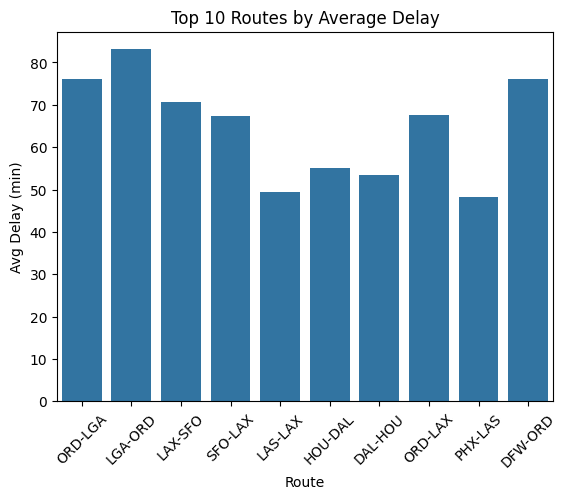

In [0]:
# Route-Level Analysis

df["Route"] = df["Origin"] + "-" + df["Dest"]

route_delay = (
    df.groupby("Route")
    .agg(flights=("FlightNum","count"), avg_delay=("ArrDelay","mean"))
    .sort_values("flights", ascending=False)
    .head(10)
)

sns.barplot(x="Route", y="avg_delay", data=route_delay)
plt.title("Top 10 Routes by Average Delay")
plt.xticks(rotation=45)
plt.ylabel("Avg Delay (min)")
plt.show()

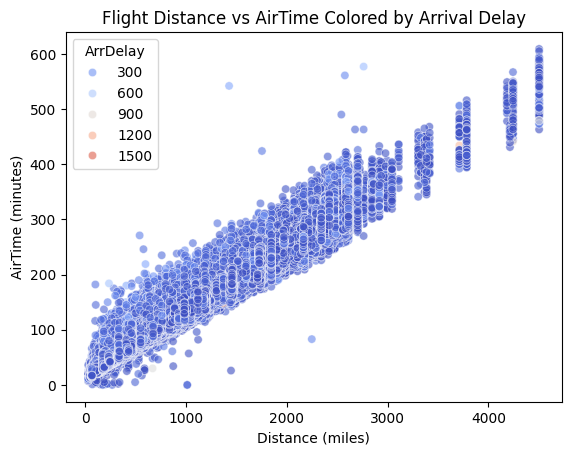

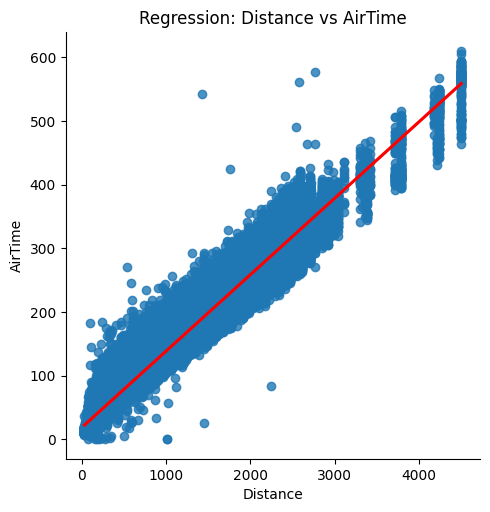

In [0]:
# Flight Distance vs AirTime Relationship

sns.scatterplot(x="Distance", y="AirTime", hue="ArrDelay", data=df, palette="coolwarm", alpha=0.6)
plt.title("Flight Distance vs AirTime Colored by Arrival Delay")
plt.xlabel("Distance (miles)")
plt.ylabel("AirTime (minutes)")
plt.show()

# Regression line
sns.lmplot(x="Distance", y="AirTime", data=df, line_kws={"color":"red"})
plt.title("Regression: Distance vs AirTime")
plt.show()

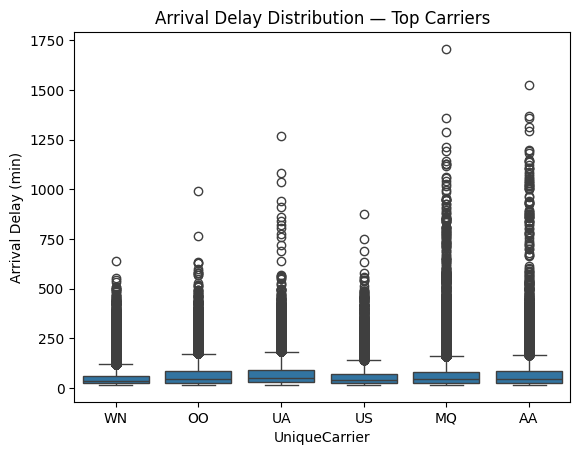

In [0]:
# Outlier Detection — Boxplots for Delay Distribution

top_carriers = df["UniqueCarrier"].value_counts().head(6).index

sns.boxplot(data=df[df["UniqueCarrier"].isin(top_carriers)], x="UniqueCarrier", y="ArrDelay")
plt.title("Arrival Delay Distribution — Top Carriers")
plt.ylabel("Arrival Delay (min)")
plt.show()

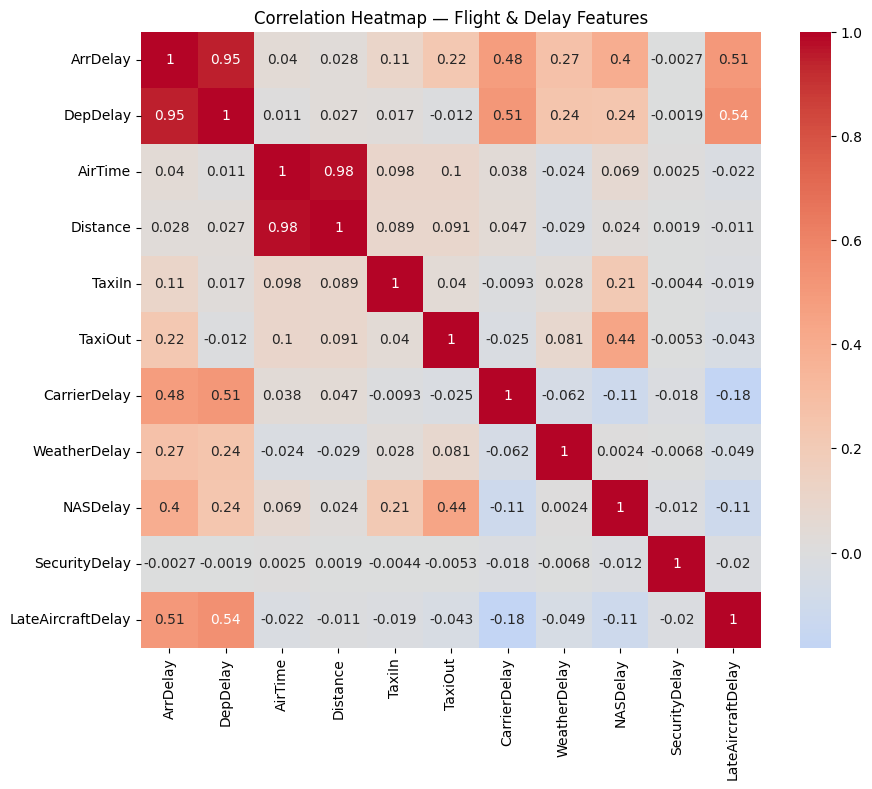

In [0]:
# Correlation & Heatmap

# Choose numeric columns
num_cols = [
    "ArrDelay","DepDelay","AirTime","Distance","TaxiIn","TaxiOut",
    "CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"
]

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Flight & Delay Features")
plt.show()

In [0]:
# Composite metric combining mean delay, cancellation %, and distance efficiency
df["Cancelled"] = df["Cancelled"].replace({"N":0,"Y":1}).astype(int)

carrier_score = df.groupby("UniqueCarrier").agg({
    "ArrDelay":"mean",
    "Cancelled":"mean",
    "Distance":"mean"
}).rename(columns={"ArrDelay":"MeanArrDelay","Cancelled":"CancelRate","Distance":"MeanDistance"})

# Normalize values
carrier_score = (carrier_score - carrier_score.min()) / (carrier_score.max() - carrier_score.min())
carrier_score["PerformanceScore"] = 1 - (0.6*carrier_score["MeanArrDelay"] + 0.3*carrier_score["CancelRate"] - 0.1*carrier_score["MeanDistance"])

carrier_score = carrier_score.sort_values("PerformanceScore", ascending=False)
display(carrier_score.head(10))

MeanArrDelay,CancelRate,MeanDistance,PerformanceScore
0.768907700390521,null,1.0,null
0.5044038477632453,null,0.732579833483624,null
1.0,null,0.9870325928751238,null
0.5605548497651084,null,0.852874545843885,null
0.6873772571196326,null,0.06207093344479917,null
0.0,null,0.7527401727496585,null
0.4429302718936819,null,0.9621215996516939,null
0.7218982378805839,null,0.0,null
0.7513660071947663,null,0.015297905459697465,null
0.8964634262284331,null,0.9341780056996474,null
